In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df = pd.read_csv("/content/drive/MyDrive/DATA/heart_disease_uci.csv")
print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)
df.info()

Dataset loaded successfully!
Shape of dataset: (920, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [3]:
print("\nDuplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("After removing duplicates:", df.shape)
print("Missing values:\n", df.isnull().sum())


Duplicate rows: 0
After removing duplicates: (920, 16)
Missing values:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [4]:
def remove_outlier(col):
    Q1, Q3 = col.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower_range = Q1 - (1.5 * IQR)
    upper_range = Q3 + (1.5 * IQR)
    return lower_range, upper_range
num_cols = df.select_dtypes(include=np.number).columns

for i in num_cols:
    lower, upper = remove_outlier(df[i])
    df[i] = np.where(df[i] < lower, lower, df[i])
    df[i] = np.where(df[i] > upper, upper, df[i])

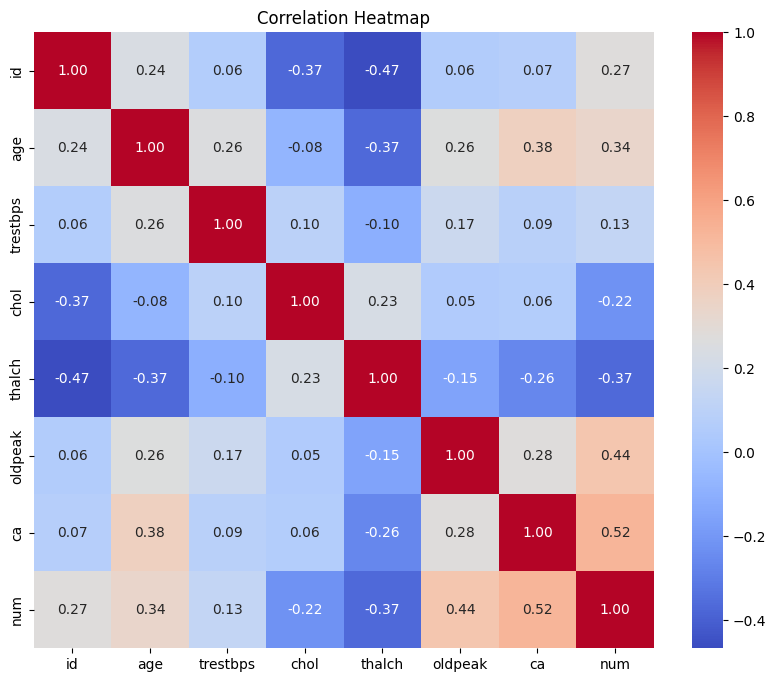

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [6]:
cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("\nEncoding Completed!")
df.head()


Encoding Completed!


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1.0,63.0,1,0,3,145.0,233.0,1,0,150.0,0,2.3,0,0.0,0,0.0
1,2.0,67.0,1,0,0,160.0,286.0,0,0,108.0,1,1.5,1,2.5,1,2.0
2,3.0,67.0,1,0,0,120.0,229.0,0,0,129.0,1,2.6,1,2.0,2,1.0
3,4.0,37.0,1,0,2,130.0,250.0,0,1,187.0,0,3.5,0,0.0,1,0.0
4,5.0,41.0,0,0,1,130.0,204.0,0,0,172.0,0,1.4,2,0.0,1,0.0


In [7]:
X = df.drop('num', axis=1)
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
print("\nData split successfully!")
print("Training data:", X_train.shape, "Test data:", X_test.shape)


Data split successfully!
Training data: (644, 15) Test data: (276, 15)


In [8]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [9]:
model = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


Model Accuracy: 63.77%


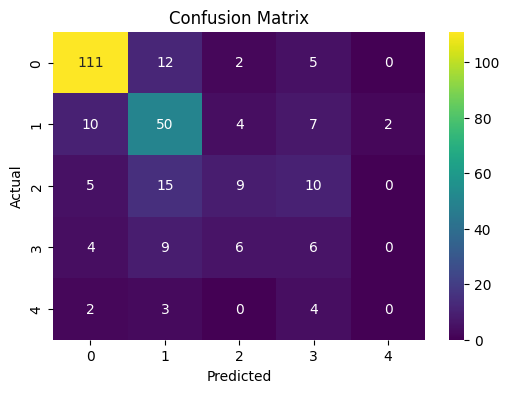


Sensitivity: 0.917
Specificity: 0.806
Precision: 0.902
Accuracy: 0.880


In [10]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy*100:.2f}%")

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

TP = conf_matrix[0][0]
TN = conf_matrix[1][1]
FP = conf_matrix[0][1]
FN = conf_matrix[1][0]

print(f"\nSensitivity: {TP/(TP+FN):.3f}")
print(f"Specificity: {TN/(TN+FP):.3f}")
print(f"Precision: {TP/(TP+FP):.3f}")
print(f"Accuracy: {(TP+TN)/(TP+TN+FP+FN):.3f}")

In [11]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           n_jobs=-1,
                           verbose=1)

grid_search.fit(X_train, y_train)
print("\nBest Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.6459682677678765



Tuned Model Test Accuracy: 0.644927536231884


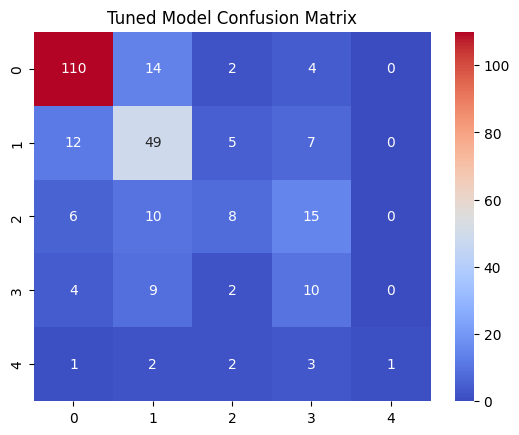

In [12]:
best_model = grid_search.best_estimator_
y_test_pred_tuned = best_model.predict(X_test)
print("\nTuned Model Test Accuracy:", accuracy_score(y_test, y_test_pred_tuned))

conf_matrix_tuned = confusion_matrix(y_test, y_test_pred_tuned)
sns.heatmap(conf_matrix_tuned, annot=True, fmt='d', cmap='coolwarm')
plt.title("Tuned Model Confusion Matrix")
plt.show()

In [13]:
joblib.dump(best_model, "best_random_forest_model.joblib")
print("\nModel saved successfully as 'best_random_forest_model.joblib'")


Model saved successfully as 'best_random_forest_model.joblib'
